# Open Sonar Datasets - Exploratory Data Analysis

This notebook analyzes the open-source sonar datasets compiled by the REMARO network.

**Source**: [OpenSonarDatasets Repository](https://github.com/remaro-network/OpenSonarDatasets)

**Paper**: M. Aubard, A. Madureira, L. Teixeira and J. Pinto, *Sonar-Based Deep Learning in Underwater Robotics: Overview, Robustness, and Challenges*, IEEE Journal of Oceanic Engineering, 2025.

---

## Dataset Overview

Analyzing 21 open-source sonar datasets covering:
- **Sonar Types**: SSS, FLS, MSIS, MBES, SAS
- **Tasks**: Classification, Object Detection, Segmentation, SLAM
- **Years**: 2010-2025

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


## 1. Dataset Collection

In [2]:
# Create structured dataset from the repository table
datasets = [
    {"name": "Northern Adriatic Reefs", "sonar": "SSS", "data_type": "GeoTIFF", "num_samples": 7, "labels": "Reefs", "annotation": "None", "setup": True, "year": 2010, "has_paper": False},
    {"name": "Lago Grey", "sonar": "SSS", "data_type": "Raw", "num_samples": None, "labels": "Glacier, Walls", "annotation": "None", "setup": True, "year": 2019, "has_paper": True},
    {"name": "UCI ML", "sonar": "Unknown", "data_type": "Raw", "num_samples": 211, "labels": "Mines, Rocks", "annotation": "Classification", "setup": False, "year": None, "has_paper": False},
    {"name": "SeabedObjects-KLSG", "sonar": "SSS", "data_type": "Images", "num_samples": 1190, "labels": "Wrecks, Humans, Mines", "annotation": "Classification", "setup": False, "year": 2020, "has_paper": True},
    {"name": "Marine_PULSE", "sonar": "SSS", "data_type": "Images", "num_samples": 627, "labels": "Pipes, Mounds, Platforms", "annotation": "Classification", "setup": False, "year": 2023, "has_paper": True},
    {"name": "NKSID", "sonar": "FLS", "data_type": "Images", "num_samples": 2617, "labels": "Infrastructures, Propellers, Tires", "annotation": "Classification", "setup": True, "year": 2024, "has_paper": True},
    {"name": "UATD", "sonar": "FLS", "data_type": "Images", "num_samples": 9200, "labels": "Tires, Mannequins, Boxes", "annotation": "Object Detection", "setup": True, "year": 2022, "has_paper": True},
    {"name": "SSS for Mine Detection", "sonar": "SSS", "data_type": "Images", "num_samples": 1170, "labels": "Mines", "annotation": "Object Detection", "setup": False, "year": 2024, "has_paper": True},
    {"name": "SWDD", "sonar": "SSS", "data_type": "Images", "num_samples": 7904, "labels": "Walls", "annotation": "Object Detection", "setup": True, "year": 2024, "has_paper": True},
    {"name": "SubPipe", "sonar": "SSS+Multi", "data_type": "Images", "num_samples": 10030, "labels": "Pipelines", "annotation": "Object Detection", "setup": True, "year": 2024, "has_paper": True},
    {"name": "UXO", "sonar": "FLS", "data_type": "Images/Raw", "num_samples": 74437, "labels": "Unexploded Ordnances", "annotation": "Object Detection", "setup": True, "year": 2024, "has_paper": True},
    {"name": "MDT", "sonar": "FLS", "data_type": "Images", "num_samples": 2471, "labels": "Infrastructures, Debris", "annotation": "Segmentation", "setup": True, "year": 2021, "has_paper": True},
    {"name": "NNSSS", "sonar": "SSS", "data_type": "Images", "num_samples": 10, "labels": "Sea Grass, Rocks, Sands", "annotation": "Segmentation", "setup": False, "year": 2020, "has_paper": True},
    {"name": "SASSED", "sonar": "SAS", "data_type": "Images", "num_samples": 129, "labels": "Muds, Sea Grass, Rocks, Sands", "annotation": "Segmentation", "setup": False, "year": 2023, "has_paper": False},
    {"name": "Seafloor Sediments", "sonar": "SSS", "data_type": "Images", "num_samples": 434164, "labels": "Rocks, Marine life", "annotation": "Segmentation", "setup": True, "year": 2023, "has_paper": True},
    {"name": "DIDSON", "sonar": "FLS", "data_type": "Images", "num_samples": 1000, "labels": "Fishes Species", "annotation": "Segmentation", "setup": True, "year": 2022, "has_paper": True},
    {"name": "AI4Shipwreck", "sonar": "SSS", "data_type": "Images", "num_samples": 286, "labels": "Shipwrecks", "annotation": "Segmentation", "setup": True, "year": 2024, "has_paper": True},
    {"name": "Cave Sonar", "sonar": "MSIS+Multi", "data_type": "Rosbag", "num_samples": None, "labels": "Cave Seabed", "annotation": "SLAM", "setup": True, "year": 2017, "has_paper": True},
    {"name": "Aurora", "sonar": "MBES+SSS+Multi", "data_type": "Raw", "num_samples": None, "labels": "Seabed, Marine habitats", "annotation": "SLAM", "setup": True, "year": 2020, "has_paper": True},
    {"name": "MBES-Slam", "sonar": "MBES", "data_type": "Rosbag", "num_samples": 4, "labels": "Seabed", "annotation": "SLAM", "setup": True, "year": 2022, "has_paper": True},
    {"name": "BenthiCat", "sonar": "SSS+Multi", "data_type": "Images/Tiles", "num_samples": 950000, "labels": "26 classes -> 12 categories", "annotation": "Segmentation", "setup": True, "year": 2025, "has_paper": True},
]

df = pd.DataFrame(datasets)

print(f"Total datasets: {len(df)}")
print(f"\nDataset columns: {list(df.columns)}")
df.head(10)

Total datasets: 21

Dataset columns: ['name', 'sonar', 'data_type', 'num_samples', 'labels', 'annotation', 'setup', 'year', 'has_paper']


,name,sonar,data_type,num_samples,labels,annotation,setup,year,has_paper
0,Northern Adriatic Reefs,SSS,GeoTIFF,7.0,Reefs,None,True,2010.0,False
1,Lago Grey,SSS,Raw,NaN,"Glacier, Walls",None,True,2019.0,True
2,UCI ML,Unknown,Raw,211.0,"Mines, Rocks",Classification,False,NaN,False
3,SeabedObjects-KLSG,SSS,Images,1190.0,"Wrecks, Humans, Mines",Classification,False,2020.0,True
4,Marine_PULSE,SSS,Images,627.0,"Pipes, Mounds, Platforms",Classification,False,2023.0,True
5,NKSID,FLS,Images,2617.0,"Infrastructures, Propellers, Tires",Classification,True,2024.0,True
6,UATD,FLS,Images,9200.0,"Tires, Mannequins, Boxes",Object Detection,True,2022.0,True
7,SSS for Mine Detection,SSS,Images,1170.0,Mines,Object Detection,False,2024.0,True
8,SWDD,SSS,Images,7904.0,Walls,Object Detection,True,2024.0,True
9,SubPipe,SSS+Multi,Images,10030.0,Pipelines,Object Detection,True,2024.0,True


## 2. Basic Statistics

In [3]:
print("="*60)
print("SONAR DATASETS - KEY STATISTICS")
print("="*60)

print(f"\n📊 Overall Statistics:")
print(f"  Total Datasets: {len(df)}")
print(f"  Year Range: {df['year'].min():.0f} - {df['year'].max():.0f}")
print(f"  Datasets with Papers: {df['has_paper'].sum()} ({df['has_paper'].sum()/len(df)*100:.1f}%)")
print(f"  Datasets with Setup Info: {df['setup'].sum()} ({df['setup'].sum()/len(df)*100:.1f}%)")

# Sample counts (excluding None values)
sample_stats = df[df['num_samples'].notna()]['num_samples']
print(f"\n📈 Sample Size Statistics (for datasets with counts):")
print(f"  Total Samples: {sample_stats.sum():,.0f}")
print(f"  Average: {sample_stats.mean():,.0f}")
print(f"  Median: {sample_stats.median():,.0f}")
print(f"  Largest: {sample_stats.max():,.0f} ({df.loc[df['num_samples'].idxmax(), 'name']})")
print(f"  Smallest: {sample_stats.min():,.0f} ({df.loc[df['num_samples'].idxmin(), 'name']})")

print(f"\n🎯 Task Distribution:")
task_counts = df['annotation'].value_counts()
for task, count in task_counts.items():
    print(f"  {task}: {count} datasets ({count/len(df)*100:.1f}%)")

print(f"\n🔊 Sonar Type Distribution:")
sonar_counts = df['sonar'].value_counts()
for sonar, count in sonar_counts.items():
    print(f"  {sonar}: {count} datasets ({count/len(df)*100:.1f}%)")

SONAR DATASETS - KEY STATISTICS

📊 Overall Statistics:
  Total Datasets: 21
  Year Range: 2010 - 2025
  Datasets with Papers: 18 (85.7%)
  Datasets with Setup Info: 15 (71.4%)

📈 Sample Size Statistics (for datasets with counts):
  Total Samples: 1,495,457
  Average: 83,081
  Median: 1,180
  Largest: 950,000 (BenthiCat)
  Smallest: 4 (MBES-Slam)

🎯 Task Distribution:
  Segmentation: 7 datasets (33.3%)
  Object Detection: 5 datasets (23.8%)
  Classification: 4 datasets (19.0%)
  SLAM: 3 datasets (14.3%)
  None: 2 datasets (9.5%)

🔊 Sonar Type Distribution:
  SSS: 9 datasets (42.9%)
  FLS: 5 datasets (23.8%)
  SSS+Multi: 2 datasets (9.5%)
  Unknown: 1 datasets (4.8%)
  SAS: 1 datasets (4.8%)
  MSIS+Multi: 1 datasets (4.8%)
  MBES+SSS+Multi: 1 datasets (4.8%)
  MBES: 1 datasets (4.8%)


## 3. Sonar Type Analysis

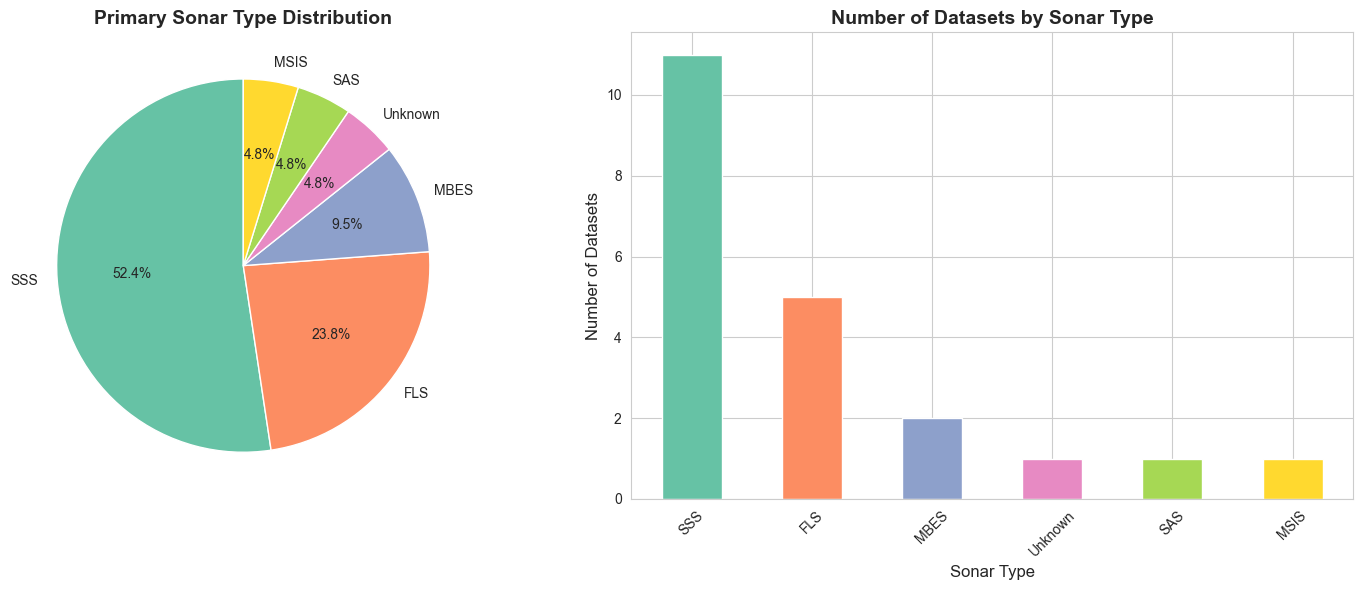


SONAR TYPE DEFINITIONS
  SSS    - Side-Scan Sonar - Wide coverage, high-resolution seabed imaging
  FLS    - Forward-Looking Sonar - Real-time obstacle detection
  MSIS   - Mechanical Scanning Imaging Sonar - 360° scanning capability
  MBES   - Multi-Beam Echo Sounder - Bathymetric mapping
  SAS    - Synthetic Aperture Sonar - Ultra-high resolution imaging


In [4]:
# Extract primary sonar types (handle multi-sensor datasets)
def extract_primary_sonar(sonar_str):
    if pd.isna(sonar_str) or sonar_str == "Unknown":
        return "Unknown"
    # Get the first sonar type if multiple
    return sonar_str.split("+")[0]

df['primary_sonar'] = df['sonar'].apply(extract_primary_sonar)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart for primary sonar types
sonar_counts = df['primary_sonar'].value_counts()
colors = sns.color_palette('Set2', len(sonar_counts))
axes[0].pie(sonar_counts.values, labels=sonar_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=colors)
axes[0].set_title('Primary Sonar Type Distribution', fontsize=14, fontweight='bold')

# Bar chart with counts
sonar_counts.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Number of Datasets by Sonar Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sonar Type', fontsize=12)
axes[1].set_ylabel('Number of Datasets', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Sonar type definitions
print("\n" + "="*60)
print("SONAR TYPE DEFINITIONS")
print("="*60)
sonar_types = {
    "SSS": "Side-Scan Sonar - Wide coverage, high-resolution seabed imaging",
    "FLS": "Forward-Looking Sonar - Real-time obstacle detection",
    "MSIS": "Mechanical Scanning Imaging Sonar - 360° scanning capability",
    "MBES": "Multi-Beam Echo Sounder - Bathymetric mapping",
    "SAS": "Synthetic Aperture Sonar - Ultra-high resolution imaging"
}
for sonar, description in sonar_types.items():
    print(f"  {sonar:6} - {description}")

## 4. Annotation Task Analysis

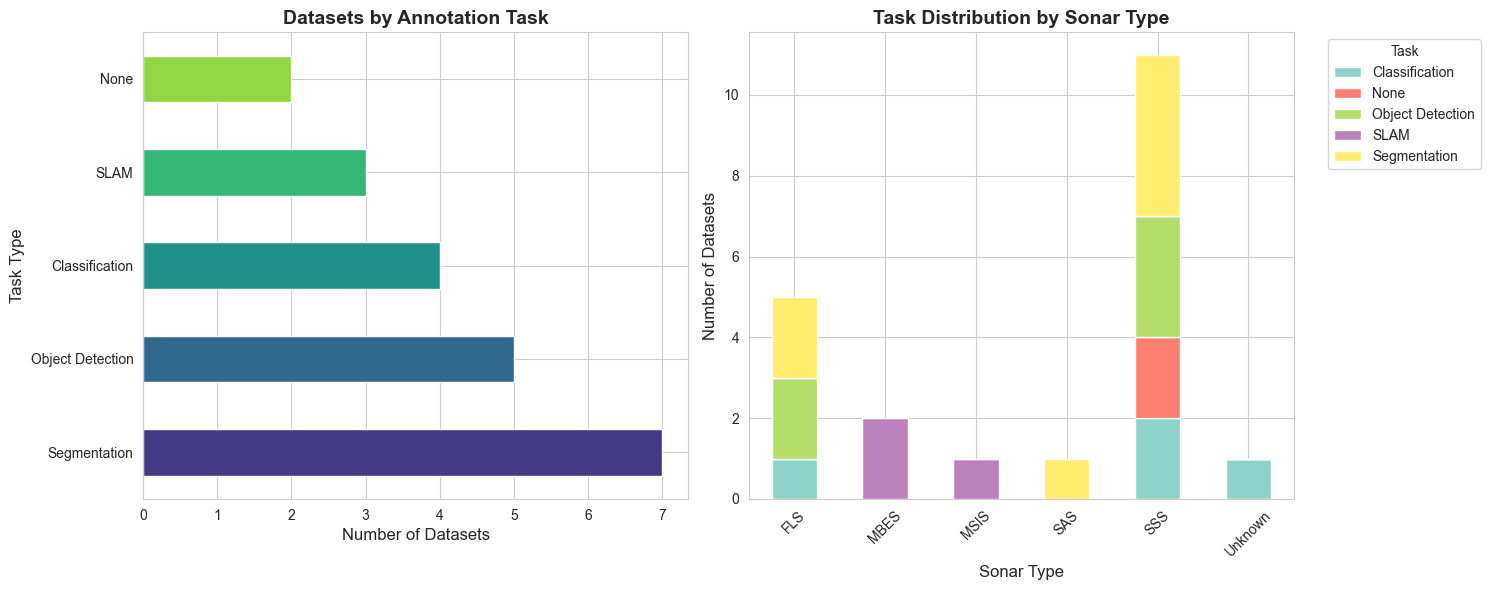


TASK COMPLEXITY RANKING
  None                 - No annotations - raw data only                     [2 datasets]
  Classification       - Image-level labels (low complexity)                [4 datasets]
  Object Detection     - Bounding boxes + labels (medium complexity)        [5 datasets]
  Segmentation         - Pixel-level annotations (high complexity)          [7 datasets]
  SLAM                 - Simultaneous Localization and Mapping (specialized) [3 datasets]


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Task distribution
task_counts = df['annotation'].value_counts()
colors = sns.color_palette('viridis', len(task_counts))

# Horizontal bar chart
task_counts.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Datasets by Annotation Task', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Datasets', fontsize=12)
axes[0].set_ylabel('Task Type', fontsize=12)

# Stacked bar: Task by Sonar Type
task_sonar = pd.crosstab(df['primary_sonar'], df['annotation'])
task_sonar.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set3')
axes[1].set_title('Task Distribution by Sonar Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sonar Type', fontsize=12)
axes[1].set_ylabel('Number of Datasets', fontsize=12)
axes[1].legend(title='Task', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("TASK COMPLEXITY RANKING")
print("="*60)
task_info = {
    "None": "No annotations - raw data only",
    "Classification": "Image-level labels (low complexity)",
    "Object Detection": "Bounding boxes + labels (medium complexity)",
    "Segmentation": "Pixel-level annotations (high complexity)",
    "SLAM": "Simultaneous Localization and Mapping (specialized)"
}
for task, desc in task_info.items():
    count = len(df[df['annotation'] == task])
    print(f"  {task:20} - {desc:50} [{count} datasets]")

## 5. Temporal Analysis

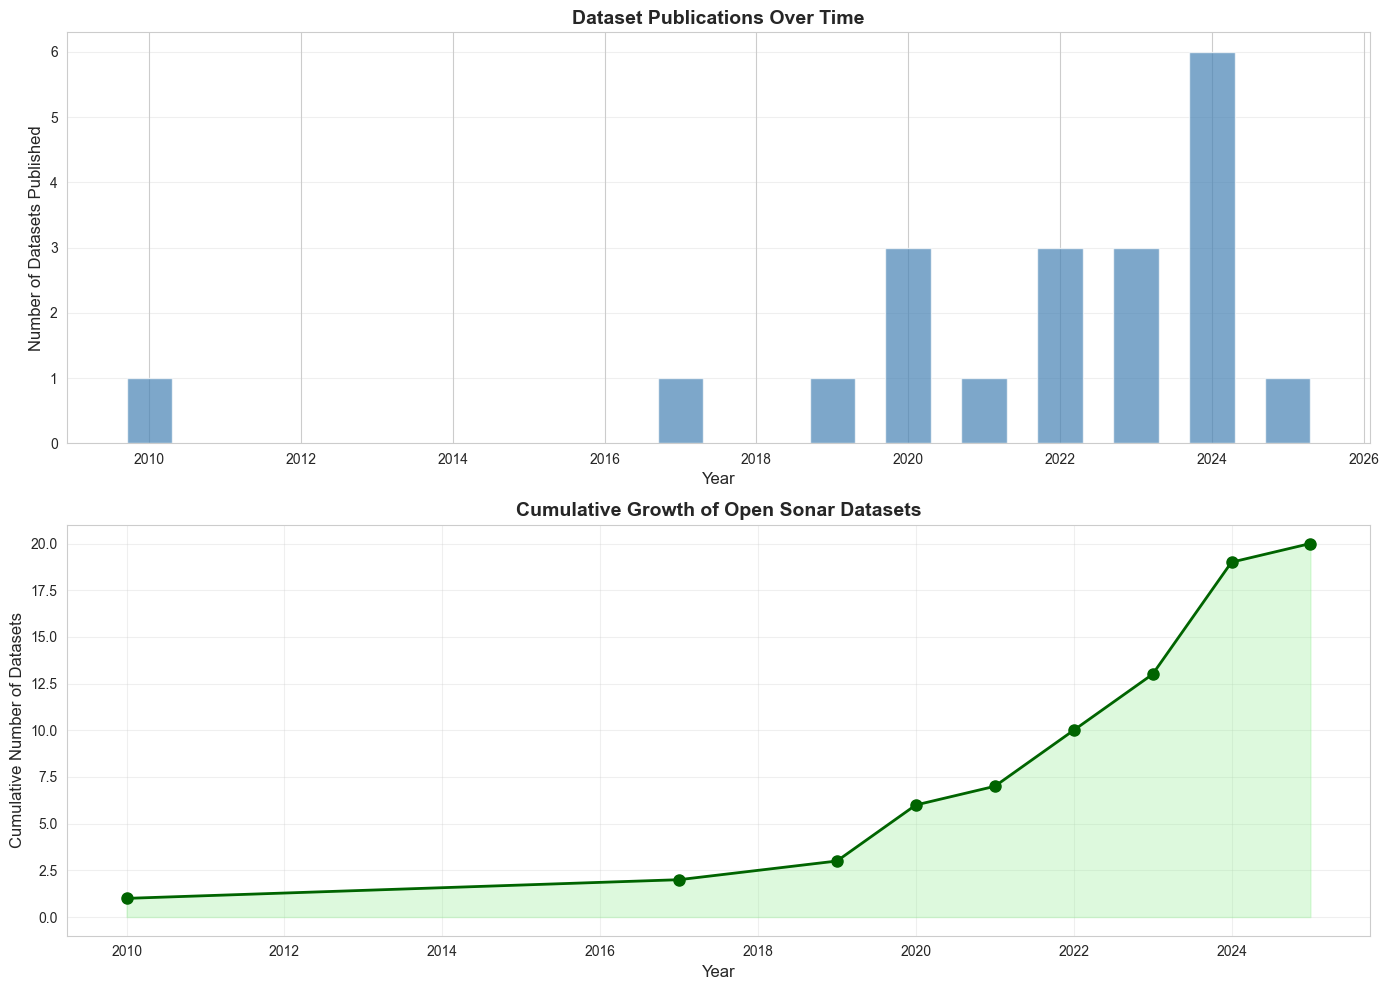


📈 Datasets published in 2024: 6
📈 Datasets published since 2020: 17
📈 Growth rate (2020-2024): 3.4 datasets/year


In [6]:
# Filter out datasets without year information
df_with_year = df[df['year'].notna()].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Timeline of dataset publications
year_counts = df_with_year['year'].value_counts().sort_index()
axes[0].bar(year_counts.index, year_counts.values, color='steelblue', alpha=0.7, width=0.6)
axes[0].set_title('Dataset Publications Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Number of Datasets Published', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Cumulative datasets over time
cumulative = year_counts.sort_index().cumsum()
axes[1].plot(cumulative.index, cumulative.values, marker='o', linewidth=2, 
             markersize=8, color='darkgreen')
axes[1].fill_between(cumulative.index, cumulative.values, alpha=0.3, color='lightgreen')
axes[1].set_title('Cumulative Growth of Open Sonar Datasets', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Cumulative Number of Datasets', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Recent trends
recent_2024 = len(df_with_year[df_with_year['year'] == 2024])
print(f"\n📈 Datasets published in 2024: {recent_2024}")
print(f"📈 Datasets published since 2020: {len(df_with_year[df_with_year['year'] >= 2020])}")
print(f"📈 Growth rate (2020-2024): {len(df_with_year[df_with_year['year'] >= 2020]) / 5:.1f} datasets/year")

## 6. Dataset Size Analysis

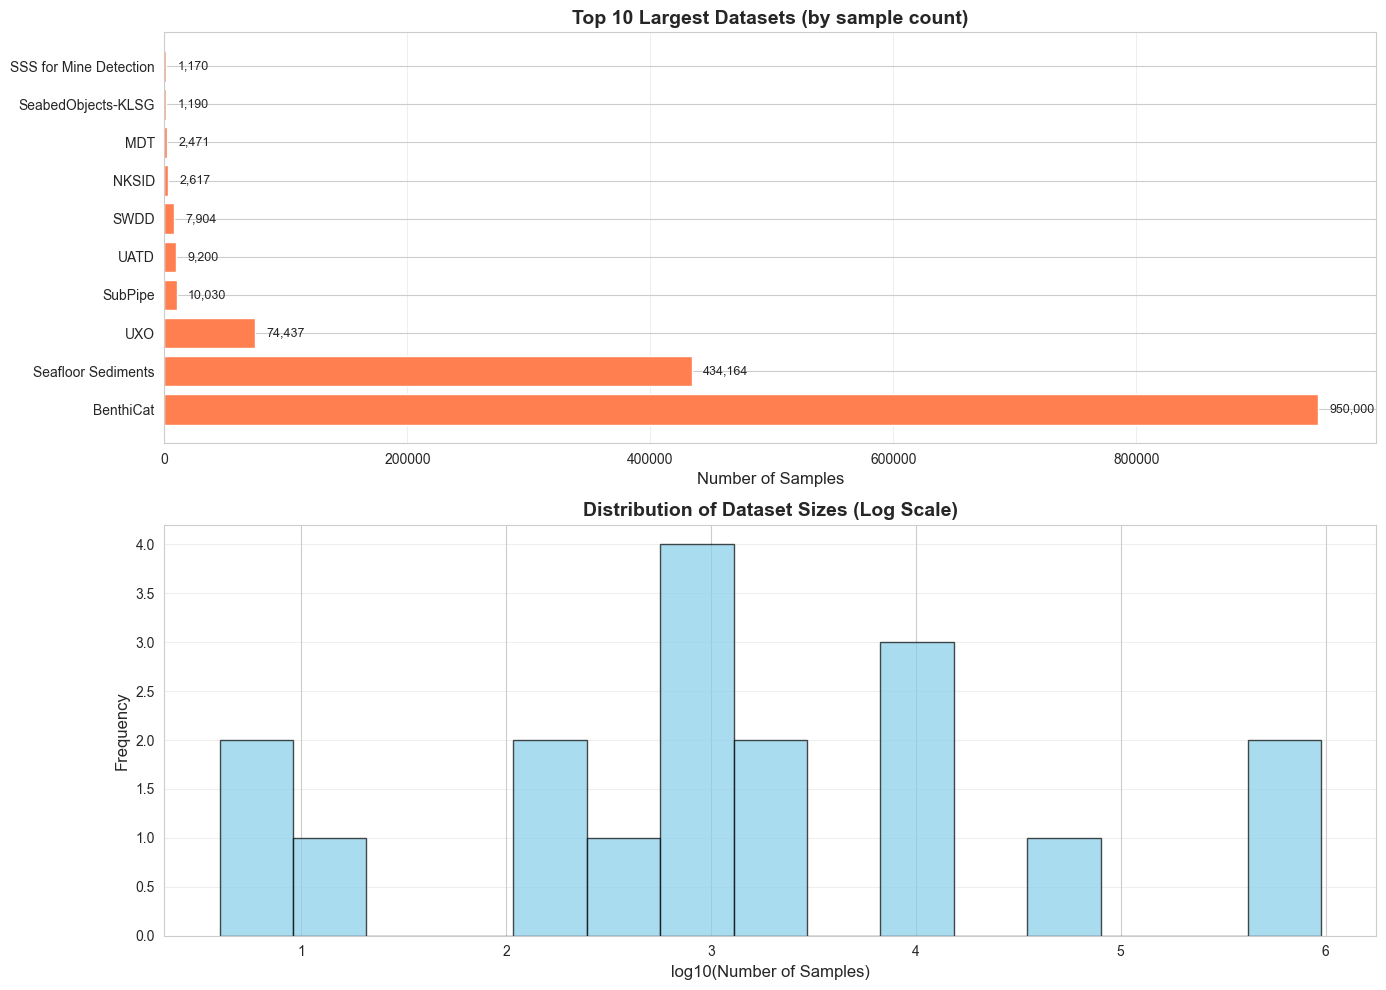


DATASET SIZE CATEGORIES
  Small (<1K samples):     7 datasets
  Medium (1K-10K):         7 datasets
  Large (10K-100K):        2 datasets
  Extra Large (>100K):     2 datasets


In [7]:
# Filter datasets with sample counts
df_with_samples = df[df['num_samples'].notna()].copy()
df_with_samples = df_with_samples.sort_values('num_samples', ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top datasets by size
top_10 = df_with_samples.head(10)
axes[0].barh(range(len(top_10)), top_10['num_samples'], color='coral')
axes[0].set_yticks(range(len(top_10)))
axes[0].set_yticklabels(top_10['name'])
axes[0].set_xlabel('Number of Samples', fontsize=12)
axes[0].set_title('Top 10 Largest Datasets (by sample count)', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Add values on bars
for i, v in enumerate(top_10['num_samples']):
    axes[0].text(v + max(top_10['num_samples'])*0.01, i, f'{v:,.0f}', 
                va='center', fontsize=9)

# Distribution of dataset sizes (log scale)
axes[1].hist(np.log10(df_with_samples['num_samples']), bins=15, 
            color='skyblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('log10(Number of Samples)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Dataset Sizes (Log Scale)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Size categories
print("\n" + "="*60)
print("DATASET SIZE CATEGORIES")
print("="*60)
small = len(df_with_samples[df_with_samples['num_samples'] < 1000])
medium = len(df_with_samples[(df_with_samples['num_samples'] >= 1000) & (df_with_samples['num_samples'] < 10000)])
large = len(df_with_samples[(df_with_samples['num_samples'] >= 10000) & (df_with_samples['num_samples'] < 100000)])
xlarge = len(df_with_samples[df_with_samples['num_samples'] >= 100000])

print(f"  Small (<1K samples):     {small} datasets")
print(f"  Medium (1K-10K):         {medium} datasets")
print(f"  Large (10K-100K):        {large} datasets")
print(f"  Extra Large (>100K):     {xlarge} datasets")

## 7. Object Label Analysis

OBJECT LABEL FREQUENCY
Total unique labels: 28

Most common labels:
  Rocks                          - 4 datasets
  Mines                          - 3 datasets
  Walls                          - 2 datasets
  Infrastructures                - 2 datasets
  Tires                          - 2 datasets
  Sea Grass                      - 2 datasets
  Sands                          - 2 datasets
  Seabed                         - 2 datasets
  Reefs                          - 1 datasets
  Glacier                        - 1 datasets
  Wrecks                         - 1 datasets
  Humans                         - 1 datasets
  Pipes                          - 1 datasets
  Mounds                         - 1 datasets
  Platforms                      - 1 datasets


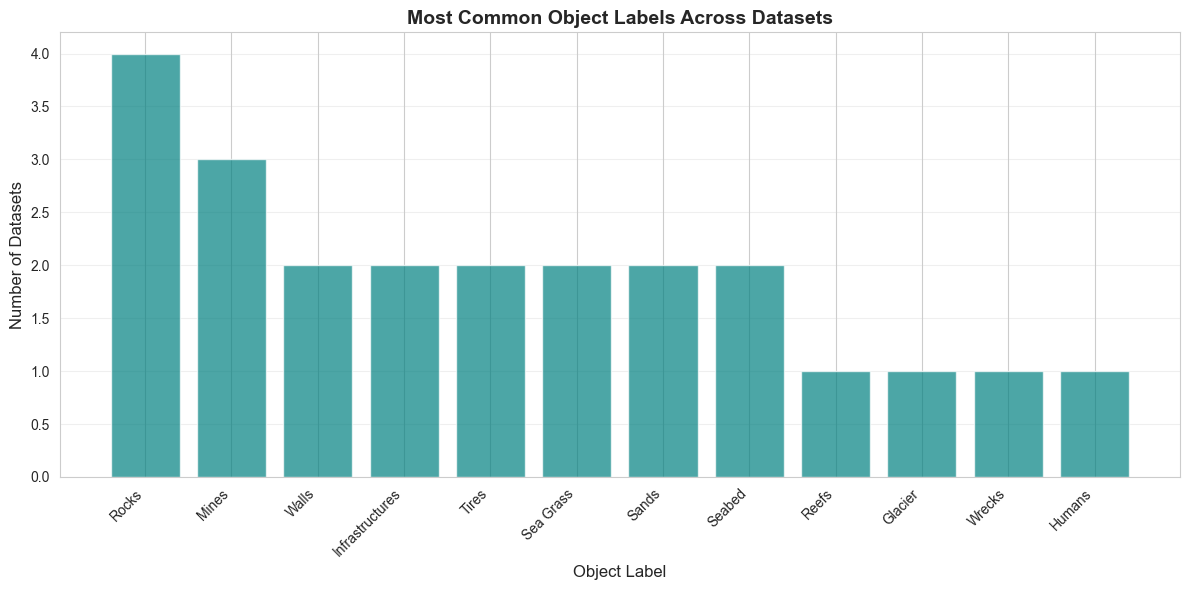


OBJECT CATEGORIES
  Natural Features          - 15 occurrences
  Man-made Objects          - 13 occurrences
  Structures                - 6 occurrences
  Marine Life               - 2 occurrences


In [8]:
# Extract all unique object labels
all_labels = []
for labels_str in df['labels'].dropna():
    # Split by comma and clean
    labels = [l.strip() for l in labels_str.split(',')]
    all_labels.extend(labels)

label_counts = Counter(all_labels)

print("="*60)
print("OBJECT LABEL FREQUENCY")
print("="*60)
print(f"Total unique labels: {len(label_counts)}\n")
print("Most common labels:")
for label, count in label_counts.most_common(15):
    print(f"  {label:30} - {count} datasets")

# Visualize top labels
top_labels = dict(label_counts.most_common(12))
plt.figure(figsize=(12, 6))
plt.bar(top_labels.keys(), top_labels.values(), color='teal', alpha=0.7)
plt.xlabel('Object Label', fontsize=12)
plt.ylabel('Number of Datasets', fontsize=12)
plt.title('Most Common Object Labels Across Datasets', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Category analysis
print("\n" + "="*60)
print("OBJECT CATEGORIES")
print("="*60)
categories = {
    "Natural Features": ["Rocks", "Sands", "Sea Grass", "Muds", "Seabed", "Reefs", "Marine habitats", "Cave Seabed", "Glacier"],
    "Man-made Objects": ["Mines", "Pipes", "Platforms", "Infrastructures", "Tires", "Boxes", "Mannequins", "Propellers", "Unexploded Ordnances"],
    "Structures": ["Walls", "Wrecks", "Shipwrecks", "Debris", "Pipelines"],
    "Marine Life": ["Marine life", "Fishes Species"]
}

for category, items in categories.items():
    count = sum([label_counts.get(item, 0) for item in items])
    print(f"  {category:25} - {count} occurrences")

## 8. Data Format Analysis

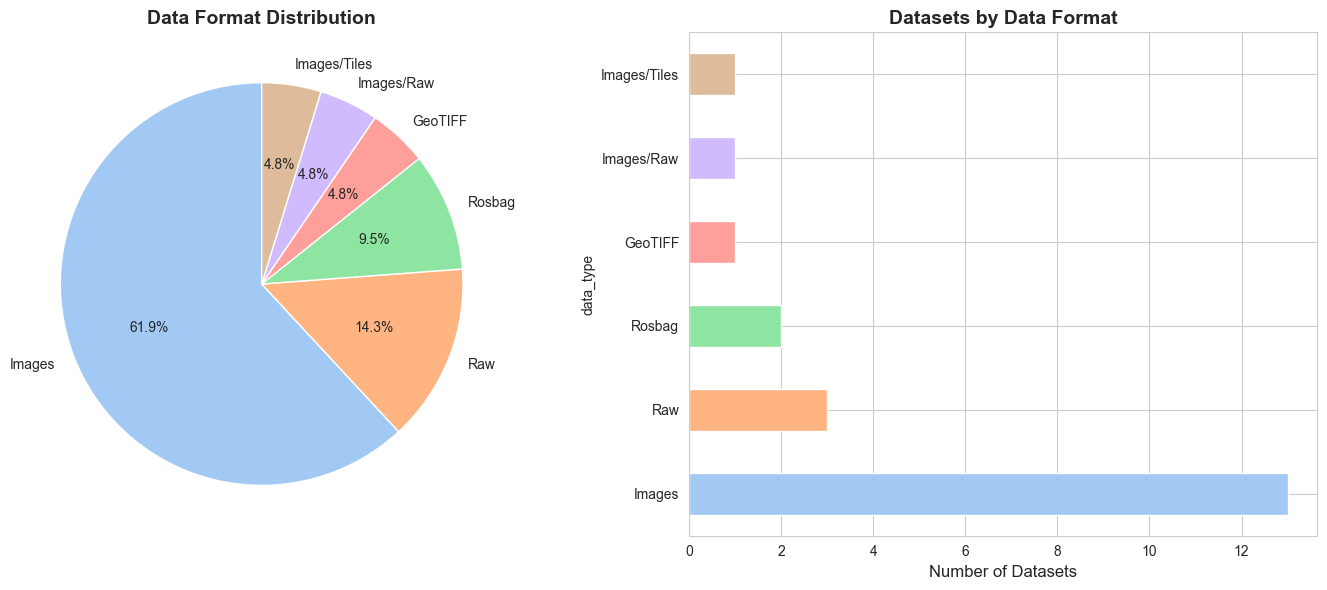


DATA FORMAT DETAILS
  Images          - Processed image files (PNG, JPG, etc.) - Ready for DL [13 datasets]
  Raw             - Raw sonar data - Requires preprocessing            [3 datasets]
  Rosbag          - ROS bag format - For robotics applications         [2 datasets]
  GeoTIFF         - Georeferenced format - For GIS integration         [1 datasets]
  Images/Raw      - Both formats available                             [1 datasets]
  Images/Tiles    - Image tiles for large-scale processing             [1 datasets]


In [9]:
# Analyze data types
data_type_counts = df['data_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors = sns.color_palette('pastel', len(data_type_counts))
axes[0].pie(data_type_counts.values, labels=data_type_counts.index, autopct='%1.1f%%',
           startangle=90, colors=colors)
axes[0].set_title('Data Format Distribution', fontsize=14, fontweight='bold')

# Bar chart
data_type_counts.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('Number of Datasets', fontsize=12)
axes[1].set_title('Datasets by Data Format', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("DATA FORMAT DETAILS")
print("="*60)
format_info = {
    "Images": "Processed image files (PNG, JPG, etc.) - Ready for DL",
    "Raw": "Raw sonar data - Requires preprocessing",
    "Rosbag": "ROS bag format - For robotics applications",
    "GeoTIFF": "Georeferenced format - For GIS integration",
    "Images/Raw": "Both formats available",
    "Images/Tiles": "Image tiles for large-scale processing"
}
for fmt, desc in format_info.items():
    count = data_type_counts.get(fmt, 0)
    if count > 0:
        print(f"  {fmt:15} - {desc:50} [{count} datasets]")

## 9. Quality & Completeness Assessment

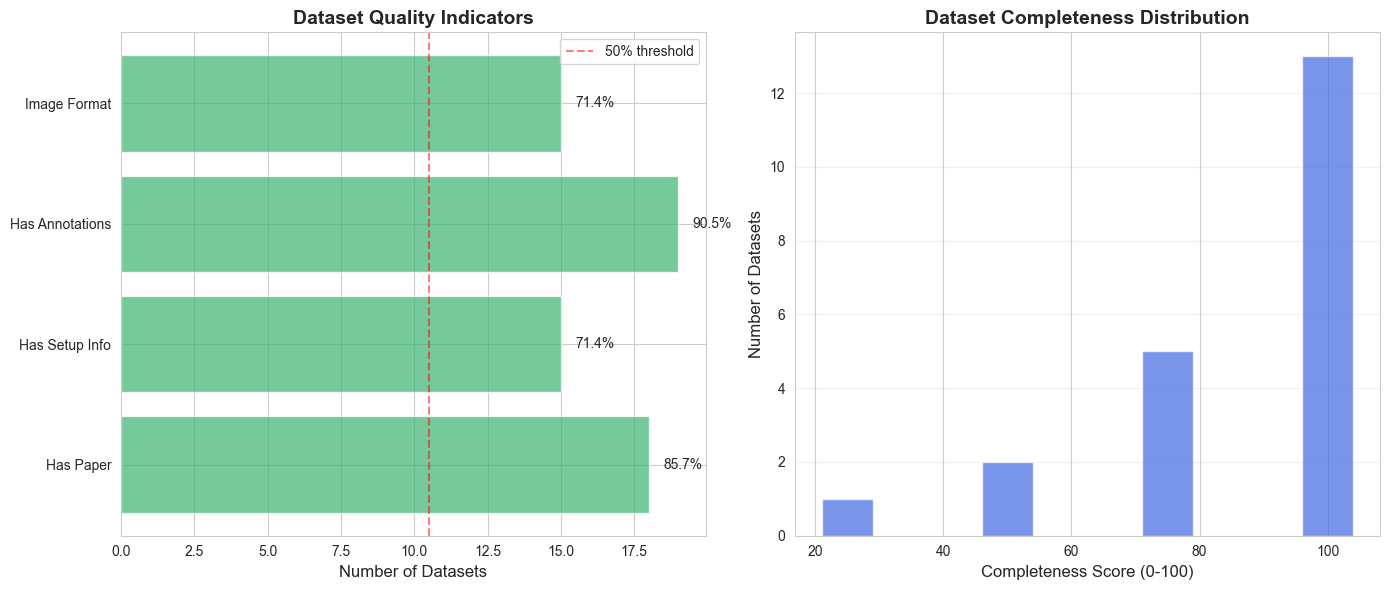


DATASET QUALITY SUMMARY
  Average completeness score: 85.7/100
  Fully complete datasets (100/100): 13
  High quality datasets (≥75): 18

  Top Quality Datasets:
    - NKSID (Score: 100/100, Classification, 2024)
    - UATD (Score: 100/100, Object Detection, 2022)
    - SWDD (Score: 100/100, Object Detection, 2024)
    - SubPipe (Score: 100/100, Object Detection, 2024)
    - UXO (Score: 100/100, Object Detection, 2024)


In [10]:
# Quality metrics
quality_metrics = {
    'Has Paper': df['has_paper'].sum(),
    'Has Setup Info': df['setup'].sum(),
    'Has Annotations': len(df[df['annotation'] != 'None']),
    'Image Format': len(df[df['data_type'].str.contains('Images', na=False)]),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Quality metrics bar chart
metrics_df = pd.DataFrame(list(quality_metrics.items()), columns=['Metric', 'Count'])
metrics_df['Percentage'] = (metrics_df['Count'] / len(df) * 100).round(1)

axes[0].barh(metrics_df['Metric'], metrics_df['Count'], color='mediumseagreen', alpha=0.7)
axes[0].set_xlabel('Number of Datasets', fontsize=12)
axes[0].set_title('Dataset Quality Indicators', fontsize=14, fontweight='bold')
axes[0].axvline(x=len(df)/2, color='red', linestyle='--', alpha=0.5, label='50% threshold')
axes[0].legend()

# Add percentages
for i, (count, pct) in enumerate(zip(metrics_df['Count'], metrics_df['Percentage'])):
    axes[0].text(count + 0.5, i, f'{pct}%', va='center', fontsize=10)

# Completeness score
df['completeness_score'] = (
    df['has_paper'].astype(int) * 25 +
    df['setup'].astype(int) * 25 +
    (df['annotation'] != 'None').astype(int) * 25 +
    df['year'].notna().astype(int) * 25
)

score_dist = df['completeness_score'].value_counts().sort_index()
axes[1].bar(score_dist.index, score_dist.values, color='royalblue', alpha=0.7, width=8)
axes[1].set_xlabel('Completeness Score (0-100)', fontsize=12)
axes[1].set_ylabel('Number of Datasets', fontsize=12)
axes[1].set_title('Dataset Completeness Distribution', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("DATASET QUALITY SUMMARY")
print("="*60)
print(f"  Average completeness score: {df['completeness_score'].mean():.1f}/100")
print(f"  Fully complete datasets (100/100): {len(df[df['completeness_score'] == 100])}")
print(f"  High quality datasets (≥75): {len(df[df['completeness_score'] >= 75])}")

# Top quality datasets
print("\n  Top Quality Datasets:")
top_quality = df.nlargest(5, 'completeness_score')[['name', 'completeness_score', 'annotation', 'year']]
for idx, row in top_quality.iterrows():
    print(f"    - {row['name']} (Score: {row['completeness_score']}/100, {row['annotation']}, {row['year']:.0f})")

## 10. Summary & Recommendations

In [11]:
print("="*80)
print("OPEN SONAR DATASETS - EXECUTIVE SUMMARY")
print("="*80)

print("\n🎯 KEY FINDINGS:\n")

# Finding 1: Dataset Growth
print("1. RAPID GROWTH IN RECENT YEARS")
recent = len(df[df['year'] >= 2020])
print(f"   - {recent} datasets published since 2020 (rapid acceleration)")
print(f"   - 2024 alone saw {len(df[df['year'] == 2024])} new datasets")
print(f"   - First dataset: {df['year'].min():.0f}, Latest: {df['year'].max():.0f}")

# Finding 2: Sonar Dominance
print("\n2. SONAR TYPE LANDSCAPE")
dominant_sonar = df['primary_sonar'].value_counts().iloc[0]
print(f"   - SSS dominates with {len(df[df['primary_sonar'] == 'SSS'])} datasets")
print(f"   - FLS is second with {len(df[df['primary_sonar'] == 'FLS'])} datasets")
print(f"   - Multi-sensor datasets increasing (4 datasets combine multiple sonars)")

# Finding 3: Task Distribution
print("\n3. DEEP LEARNING TASK COVERAGE")
seg_count = len(df[df['annotation'] == 'Segmentation'])
det_count = len(df[df['annotation'] == 'Object Detection'])
print(f"   - Segmentation: {seg_count} datasets (most common DL task)")
print(f"   - Object Detection: {det_count} datasets (critical for navigation)")
print(f"   - SLAM: {len(df[df['annotation'] == 'SLAM'])} datasets (specialized robotics)")

# Finding 4: Dataset Size
print("\n4. DATASET SCALE")
largest = df.loc[df['num_samples'].idxmax()]
print(f"   - Largest: {largest['name']} ({largest['num_samples']:,.0f} samples)")
print(f"   - Total samples across all datasets: {df['num_samples'].sum():,.0f}+")
print(f"   - Wide range: from {df['num_samples'].min():.0f} to {df['num_samples'].max():,.0f} samples")

# Finding 5: Quality
print("\n5. DATASET MATURITY")
print(f"   - {df['has_paper'].sum()}/{len(df)} datasets have associated papers")
print(f"   - {df['setup'].sum()}/{len(df)} provide experimental setup details")
print(f"   - Average completeness score: {df['completeness_score'].mean():.1f}/100")

print("\n" + "="*80)
print("💡 RECOMMENDATIONS FOR RESEARCHERS")
print("="*80)

print("\n📌 FOR BEGINNERS:")
beginner_datasets = df[(df['data_type'].str.contains('Images', na=False)) & 
                       (df['has_paper'] == True) & 
                       (df['setup'] == True)].nsmallest(3, 'num_samples')
print("   Start with these well-documented, image-based datasets:")
for idx, row in beginner_datasets.iterrows():
    print(f"   - {row['name']} ({row['annotation']}, {row['num_samples']:.0f} samples)")

print("\n📌 FOR OBJECT DETECTION:")
detection_ds = df[df['annotation'] == 'Object Detection'].nlargest(3, 'num_samples')
print("   Largest object detection datasets:")
for idx, row in detection_ds.iterrows():
    print(f"   - {row['name']} ({row['num_samples']:,.0f} samples, {row['sonar']})")

print("\n📌 FOR SEMANTIC SEGMENTATION:")
seg_ds = df[df['annotation'] == 'Segmentation'].nlargest(3, 'num_samples')
print("   Largest segmentation datasets:")
for idx, row in seg_ds.iterrows():
    print(f"   - {row['name']} ({row['num_samples']:,.0f} samples, {row['sonar']})")

print("\n📌 FOR SLAM & ROBOTICS:")
slam_ds = df[df['annotation'] == 'SLAM']
print("   SLAM-focused datasets:")
for idx, row in slam_ds.iterrows():
    print(f"   - {row['name']} ({row['sonar']}, {row['year']:.0f})")

print("\n📌 NEWEST DATASETS (2024-2025):")
newest = df[df['year'] >= 2024].sort_values('year', ascending=False)
print("   Cutting-edge datasets:")
for idx, row in newest.iterrows():
    samples_str = f"{row['num_samples']:,.0f}" if pd.notna(row['num_samples']) else "N/A"
    print(f"   - {row['name']} ({row['annotation']}, {samples_str} samples)")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE")
print("="*80)
print(f"\nSource: REMARO Network OpenSonarDatasets Repository")
print(f"Paper: IEEE Journal of Oceanic Engineering, 2025")
print(f"DOI: https://doi.org/10.1109/JOE.2025.3531933")
print(f"\nAnalyzed {len(df)} datasets spanning {df['year'].max() - df['year'].min():.0f} years of research.")

OPEN SONAR DATASETS - EXECUTIVE SUMMARY

🎯 KEY FINDINGS:

1. RAPID GROWTH IN RECENT YEARS
   - 17 datasets published since 2020 (rapid acceleration)
   - 2024 alone saw 6 new datasets
   - First dataset: 2010, Latest: 2025

2. SONAR TYPE LANDSCAPE
   - SSS dominates with 11 datasets
   - FLS is second with 5 datasets
   - Multi-sensor datasets increasing (4 datasets combine multiple sonars)

3. DEEP LEARNING TASK COVERAGE
   - Segmentation: 7 datasets (most common DL task)
   - Object Detection: 5 datasets (critical for navigation)
   - SLAM: 3 datasets (specialized robotics)

4. DATASET SCALE
   - Largest: BenthiCat (950,000 samples)
   - Total samples across all datasets: 1,495,457+
   - Wide range: from 4 to 950,000 samples

5. DATASET MATURITY
   - 18/21 datasets have associated papers
   - 15/21 provide experimental setup details
   - Average completeness score: 85.7/100

💡 RECOMMENDATIONS FOR RESEARCHERS

📌 FOR BEGINNERS:
   Start with these well-documented, image-based datasets:

## 11. Export Summary

In [12]:
# Create summary dataframe
summary_df = df[['name', 'sonar', 'annotation', 'num_samples', 'year', 'has_paper', 'setup', 'completeness_score']].copy()
summary_df = summary_df.sort_values('completeness_score', ascending=False)

# Save to CSV
output_file = 'sonar_datasets_summary.csv'
summary_df.to_csv(output_file, index=False)
print(f"✅ Summary exported to: {output_file}")

# Display top datasets
print("\n📊 Top 10 Datasets by Completeness Score:")
summary_df.head(10)

✅ Summary exported to: sonar_datasets_summary.csv

📊 Top 10 Datasets by Completeness Score:


,name,sonar,annotation,num_samples,year,has_paper,setup,completeness_score
10,UXO,FLS,Object Detection,74437.0,2024.0,True,True,100
9,SubPipe,SSS+Multi,Object Detection,10030.0,2024.0,True,True,100
19,MBES-Slam,MBES,SLAM,4.0,2022.0,True,True,100
18,Aurora,MBES+SSS+Multi,SLAM,NaN,2020.0,True,True,100
17,Cave Sonar,MSIS+Multi,SLAM,NaN,2017.0,True,True,100
16,AI4Shipwreck,SSS,Segmentation,286.0,2024.0,True,True,100
15,DIDSON,FLS,Segmentation,1000.0,2022.0,True,True,100
14,Seafloor Sediments,SSS,Segmentation,434164.0,2023.0,True,True,100
11,MDT,FLS,Segmentation,2471.0,2021.0,True,True,100
20,BenthiCat,SSS+Multi,Segmentation,950000.0,2025.0,True,True,100
